# <p align="center">**Laboratorio de Aprendizaje Estadístico**</p>

## <p align="center">**Profesor: Gabriel Alejandro Morales Ruiz**</p>

<p align="center">
  <img src="https://oci02.img.iteso.mx/Identidades-De-Instancia/ITESO/Logos%20ITESO/Logo-ITESO-Vertical-Gris.png" alt="Descripción" width="550">
</p>

## <p align="center">Proyecto 3</p>

### <p align="center">Final</p>

### <p align="center">**Fecha:** 11 de mayo de 2026</p>

### <p align="center">**Integrantes:**</p>


<p align="center">Julieta Madrigal Flores</p>
<p align="center">Gibrán Leonardo Chávez González</p>
<p align="center">Diana Fernanda Barbosa Dueñas</p>

# **Predicción del Customer Lifetime Value en Seguros Automotrices mediante Modelos de Ensamble**


# **Objetivos**

## ***Generales***
Predecir el valor de vida del cliente (Customer Lifetime Value) en una cartera de seguros automotrices mediante la implementación y comparación de modelos de ensamble de machine learning, a partir del análisis de variables demográficas, de comportamiento y de póliza.

## ***Específicos***

1. Analizar el dataset IBM Watson Marketing Customer Value identificando su origen, estructura, calidad y las relaciones entre sus variables, con el propósito de fundamentar las decisiones de preprocesamiento y modelado que se tomen a lo largo del proyecto.
2. Desarrollar el marco teórico del proyecto documentando los fundamentos de regresión lineal y sus seis problemas potenciales, árboles de decisión para regresión, bootstrap, métodos de ensamble, bagging y boosting, estableciendo la base conceptual que sustenta la elección de los modelos propuestos.
3. Diseñar e implementar un pipeline de preprocesamiento y modelado que integre de forma sistemática la transformación de variables, el entrenamiento de modelos y su evaluación, garantizando la reproducibilidad y escalabilidad del proceso.
4. Comprobar si la interacción entre dos variables resulta significativa para los modelos.
5. Ajustar un modelo de Random Forest para regresión con optimización de hiperparámetros y semilla fija, orientado a predecir el Customer Lifetime Value, documentando el proceso de selección de parámetros y los resultados obtenidos.
6. Ajustar un modelo de XGBoost para regresión con optimización de hiperparámetros y semilla fija bajo las mismas condiciones experimentales que el modelo anterior, con el fin de estimar el Customer Lifetime Value y permitir una comparación directa y equitativa entre ambos enfoques.
7. Comparar el desempeño predictivo de los modelos ajustados mediante validación cruzada k-fold, reportando la media y desviación estándar de la métrica seleccionada, para determinar de forma objetiva cuál modelo generaliza mejor sobre datos no vistos.
8. Formular conclusiones respecto a cada objetivo planteado con base en los resultados obtenidos, determinando qué modelo predice con mayor precisión el Customer Lifetime Value y qué variables del dataset resultan más influyentes en dicha predicción.

# **Marco Teórico**

## ***Regresión lineal: 6 problemas potenciales en una regresión***

La regresión lineal es uno de los métodos más importantes del aprendizaje estadístico supervisado. El objetivo es modelar la relación entre una variable respuesta cuantitativa Y y uno o más predictores X1,X2,…,Xp​, asumiendo una relación de la forma Y≈β0+β1X1+⋯+βpXp, donde los coeficientes βj​ son estimados mediante mínimos cuadrados ordinarios (OLS).
Sin embargo, la regresión lineal puede presentar problemas que comprometen la validez e interpretabilidad del modelo ajustador:

**1. No linealidad de la relación entre predictores y respuesta.** Si la relación verdadera entre X e Y no es lineal, las inferencias y predicciones del modelo serán incorrectas. La inspección de los residuales contra los valores ajustados (gráficas de residuales) permite detectar patrones no lineales que sugieren la necesidad de transformaciones o términos polinomiales.

**2. Correlación de los términos de error.** El supuesto clásico de OLS exige que los errores ε = epsilon,​ sean incorrelacionados entre sí. En datos de series de tiempo o con estructura espacial, esta correlación puede existir, lo que produce estimaciones erróneas de los errores estándar y pruebas de hipótesis inválidas.

**3. Varianza no constante de los errores (heterocedasticidad).** Si la varianza del error no es constante, los intervalos de confianza y las pruebas de significancia pierden validez. Una gráfica de residuales versus valores ajustados con forma de embudo es señal típica de heterocedasticidad; transformaciones como $log⁡(Y)$ o $sqrt(Y)$ pueden corregirla.

**4. Valores atípicos (outliers).** Un outlier es una observación cuyo valor de Y es inusual dado su  X; aunque un único outlier puede no distorsionar drásticamente los coeficientes, sí puede aumentar el RSE y distorsionar el R2.

**5. Puntos de alto apalancamiento (high leverage points).**  A diferencia de los outliers, que presentan valores inusuales de Y, los puntos de alto apalancamiento tienen valores inusuales en X. Estas observaciones tienen una influencia desproporcionada sobre la línea de regresión estimada y su eliminación puede modificar sustancialmente los coeficientes del modelo.

**6. Colinealidad.** La colinealidad ocurre cuando dos o más predictores están correlacionados entre sí. En presencia de colinealidad, resulta difícil separar los efectos individuales de los predictores, los errores estándar de los coeficientes se inflan y la potencia de las pruebas de hipótesis se reduce. El Variance Inflation Factor (VIF) es el diagnóstico estándar para detectarla.

## ***Árbol para regresión***

Un árbol de regresión es un modelo que predice una respuesta cuantitativa  Y dividiendo progresivamente el espacio de los predictores en regiones cada vez más pequeñas y homogéneas, asignando a cada región una predicción constante. La analogía más intuitiva es un diagrama de flujo de preguntas sucesivas: "¿Es X1​ mayor que cierto valor? Si sí, ¿es X2​ mayor que otro valor?...", hasta llegar a una respuesta final. Cada pregunta corresponde a una división (*split*) del espacio y la respuesta final en cada región terminal (llamada hoja o nodo terminal) es la media de los valores de Y de las observaciones de entrenamiento que cayeron en esa región.
El proceso de construcción del árbol es top-down (de arriba hacia abajo) y greedy (codicioso): en cada paso se elige la variable Xj​ y el punto de corte s que mejor dividen los datos en ese momento, sin considerar lo que ocurrirá en divisiones futuras.

El criterio de mejor división es aquel que minimiza la suma de cuadrados residual (RSS) combinada de las dos regiones resultantes: Si se deja crecer el árbol sin restricciones, este memoriza los datos de entrenamiento con regiones muy pequeñas y específicas, cayendo en sobreajuste. Para controlarlo, se aplica poda por complejidad de costo: en lugar de simplemente detener el crecimiento temprano, se deja crecer un árbol grande y luego se poda hacia atrás. La poda añade una penalización α al RSS, donde T es el número de nodos terminales y α≥0 es un parámetro de ajuste que controla el equilibrio entre ajuste y complejidad. El valor óptimo de α se selecciona mediante validación cruzada. Los árboles de regresión son altamente interpretables y capturan interacciones entre variables de forma natural, aunque presentan alta varianza: pequeños cambios en los datos de entrenamiento pueden producir árboles muy distintos.

#### Hiperparámetros de `RandomForestRegressor`

En un modelo **RandomForestRegressor**, los hiperparámetros permiten controlar la cantidad, profundidad y complejidad de los árboles que forman el bosque. Su correcta selección es importante porque influye directamente en el equilibrio entre **sesgo**, **varianza**, capacidad predictiva y riesgo de sobreajuste.

#### `n_estimators`

El hiperparámetro `n_estimators` indica el número de árboles de decisión que se construirán dentro del bosque aleatorio. En general, un mayor número de árboles permite obtener predicciones más estables, ya que el modelo promedia más resultados individuales. Sin embargo, también aumenta el tiempo de entrenamiento y el costo computacional.

#### `max_depth`

El hiperparámetro `max_depth` define la profundidad máxima que puede alcanzar cada árbol. Controla qué tan complejos pueden ser los árboles al dividir los datos. Una profundidad alta permite capturar relaciones más detalladas, pero puede provocar sobreajuste. Una profundidad baja genera modelos más simples, aunque puede limitar la capacidad predictiva.

#### `max_leaf_nodes`

El hiperparámetro `max_leaf_nodes` establece el número máximo de hojas finales que puede tener cada árbol. Las hojas representan los nodos terminales donde se generan las predicciones. Limitar este valor ayuda a controlar el tamaño del árbol y evita que el modelo aprenda patrones demasiado específicos del conjunto de entrenamiento.

#### `min_samples_split`

El hiperparámetro `min_samples_split` indica el número mínimo de observaciones necesarias para que un nodo pueda dividirse. Si este valor es bajo, el árbol puede generar muchas divisiones, aumentando su complejidad. Si es alto, el árbol se vuelve más conservador, ya que solo divide nodos con suficiente cantidad de datos.

#### `min_samples_leaf`

El hiperparámetro `min_samples_leaf` define el número mínimo de observaciones que debe contener una hoja final. Este parámetro ayuda a evitar que el árbol cree hojas con muy pocos datos, lo cual puede reducir el sobreajuste y mejorar la generalización del modelo.

#### `max_features`

El hiperparámetro `max_features` controla cuántas variables se consideran al buscar la mejor división en cada nodo. Al limitar el número de variables disponibles, se aumenta la diversidad entre los árboles del bosque. Esto puede reducir la correlación entre árboles y mejorar la capacidad de generalización.

#### `max_samples`

El hiperparámetro `max_samples` determina la proporción de observaciones que se utilizan para entrenar cada árbol cuando se emplea muestreo bootstrap. Usar solo una parte de los datos para cada árbol aumenta la variabilidad entre los árboles y puede ayudar a reducir el sobreajuste.


## ***Árbol para clasificación***


Los árboles de clasificación funcionan con la misma lógica que los árboles de regresión, con la diferencia fundamental de que la variable respuesta Y es cualitativa (categórica): se busca predecir a qué clase pertenece una observación. La predicción en cada nodo terminal es la clase mayoritaria entre las observaciones de entrenamiento que llegaron a esa hoja.
Dado que RSS no tiene sentido para respuestas categóricas, se utilizan otras medidas de impureza del nodo para decidir cómo dividir los datos. Las dos más comunes son:


**1. Índice de Gini:** mide qué tan "mezcladas" están las clases en un nodo: toma el valor 0 cuando el nodo es perfectamente puro (todas las observaciones son de la misma clase) y aumenta conforme las clases se mezclan más. Intuitivamente, $p_{mk}*(1−p_{​mk}​)$ es la probabilidad de clasificar mal una observación si se etiqueta aleatoriamente según la distribución del nodo.

**2. Entropía cruzada:** mide la cantidad de información (o desorden) en el nodo. Al igual que el índice de Gini, vale 0 en nodos puros y es máxima cuando las clases están igualmente distribuidas.


Ambas métricas producen resultados similares en la práctica. La división elegida en cada nodo es aquella que más reduce la impureza en las regiones hijas, ponderando por el tamaño de cada región. Al igual que en regresión, se aplica poda para evitar el sobreajuste, y el parámetro α\alpha α se selecciona por validación cruzada.


## ***Bootstrap***

El bootstrap es una técnica estadística de remuestreo cuya idea central es: en lugar de repetir el experimento original muchas veces para estudiar la variabilidad de un estimador, se simula esa repetición re muestreando los propios datos disponibles. Dado un conjunto de n observaciones, el procedimiento consiste en:

1. Extraer una muestra de tamaño n con reemplazo del conjunto original. Esto significa que cada observación puede aparecer cero, una o varias veces en la muestra resultante. Esta es la muestra bootstrap.
2. Calcular el estadístico de interés (por ejemplo, la media, un coeficiente de regresión, o el error de un modelo) sobre esa muestra.
3. Repetir este proceso  B veces (típicamente B=1000 o más).
4. Usar la distribución empírica de los B valores obtenidos para estimar la variabilidad del estadístico: por ejemplo, su error estándar o su intervalo de confianza.


La potencia del bootstrap radica en que no requiere supuestos sobre la distribución poblacional de los datos: deja que los datos "hablen por sí mismos". Cada muestra bootstrap actúa como una aproximación de lo que sería una nueva muestra del mismo proceso generador. En cada muestra bootstrap aproximadamente un tercio de las observaciones originales no son seleccionadas; estas se denominan observaciones out-of-bag (OOB) y tienen un rol importante en los métodos de ensamble.

## ***Ensambles de modelos***


Un método de ensamble parte de una premisa intuitiva: así como una decisión tomada por un grupo diverso de personas suele ser más acertada que la de un individuo aislado, un conjunto de modelos predictivos entrenados y combinados adecuadamente suele superar en precisión a cualquier modelo individual. Los métodos de ensamble construyen un conjunto de modelos base f1,f2,…,fB y agregan sus predicciones mediante alguna regla:

- Promediado (para regresión)
- Voto mayoritario (para clasificación): se predice la clase que más modelos eligen = moda.
- Promedio ponderado: se asigna más peso a los modelos más precisos.


La justificación estadística es clara: si se tienen B modelos con varianza y correlación entre sus predicciones, la varianza del promedio es ρσ2+((1−ρ)/B)*σ2. Cuando B es grande, el segundo término se vuelve despreciable y la varianza del ensamble queda dominada por ρσ2. Por ello, los mejores ensambles buscan modelos que sean precisos individualmente pero que cometan errores distintos entre sí (baja correlación). Existen tres razones fundamentales por las que los ensambles superan a los modelos individuales: razones estadísticas (reducen la varianza del estimador), razones computacionales (evitan quedar atrapados en mínimos locales) y razones de representación (el espacio de hipótesis del ensamble es más rico que el de cualquier modelo base).

## ***Bagging***

El *bagging* cuyo nombre proviene de *bootstrap aggregating*, es el método de ensamble más directo y fue propuesto para atacar el problema de la alta varianza de los árboles de decisión. Si un solo árbol es inestable (pequeños cambios en los datos producen árboles muy distintos), ¿por qué no entrenar muchos árboles sobre versiones ligeramente distintas de los datos y promediar sus predicciones?
El procedimiento es el siguiente:

1. Generar B muestras bootstrap del conjunto de entrenamiento original (muestras de tamaño n con reemplazo).
2. Ajustar un árbol de decisión profundo y sin podar sobre cada muestra bootstrap. Cada árbol tiene alta varianza pero bajo sesgo.
3. Combinar las B predicciones:
- En regresión: promediar las predicciones
- En clasificación: voto mayoritario entre los B árboles

El promediado estabiliza las predicciones: los errores de cada árbol se cancelan entre sí, reduciendo la varianza global sin incrementar significativamente el sesgo. Una ventaja práctica del bagging es la estimación gratuita del error de generalización mediante las observaciones out-of-bag (OOB): como cada árbol solo usa aproximadamente dos tercios de los datos, el tercio restante puede usarse para evaluar ese árbol sin necesidad de validación cruzada. El error OOB promediado sobre todos los árboles es una estimación válida del error de prueba.

## ***Boosting***
El boosting es una familia de métodos de ensamble que a diferencia del bagging, construye los modelos de manera secuencial: cada nuevo modelo no se entrena de forma independiente, sino que se enfoca deliberadamente en corregir los errores que cometieron los modelos anteriores. La intuición es parecida a la de un estudiante que repasa los temas que respondió mal en un examen anterior: cada iteración pone más atención en los casos difíciles.

El algoritmo seminal de esta familia es **AdaBoost** (Adaptive Boosting):
1. Se asigna el mismo peso wi=1/n a todas las observaciones de entrenamiento.
2. Se ajusta un clasificador débil (típicamente un árbol de decisión muy pequeño, llamado stump).
3. Las observaciones que fueron mal clasificadas reciben un peso mayor en la siguiente iteración; las correctamente clasificadas reciben un peso menor.
4. Se ajusta un nuevo clasificador débil con los datos reponderados.
5. El proceso se repite T veces. La predicción final es una combinación ponderada de todos los clasificadores, donde se le da más peso a los más precisos.


El error de entrenamiento de AdaBoost decrece exponencialmente con el número de iteraciones T, garantizando convergencia a un clasificador fuerte a partir de clasificadores que apenas superan el azar.


En regresión, la variante más utilizada es el **Gradient Boosting**, que generaliza el boosting como un proceso de optimización: en lugar de reponder observaciones, cada árbol nuevo se ajusta sobre los residuales del modelo anterior (los errores que quedan por explicar), con lo que el modelo crece iterativamente en la dirección que más reduce la función de pérdida elegida.


**XGBoost** (eXtreme Gradient Boosting)  es la implementación más eficiente y popular del gradient boosting. Sus principales contribuciones técnicas incluyen: regularización L1​ y L2​ en el proceso de construcción del árbol (lo que controla el sobreajuste de forma más efectiva que el gradient boosting clásico).

#### Hiperparámetros de `XGBRegressor`

En un modelo **XGBRegressor**, los hiperparámetros controlan la forma en que se construyen los árboles de manera secuencial. A diferencia de Random Forest, XGBoost construye árboles que corrigen los errores de los árboles anteriores. Por ello, sus hiperparámetros son fundamentales para regular la velocidad de aprendizaje, la complejidad del modelo y el riesgo de sobreajuste.

#### `n_estimators`

El hiperparámetro `n_estimators` indica el número de árboles que se construirán durante el proceso de boosting. Cada árbol intenta corregir los errores acumulados por los árboles anteriores. Un número alto de árboles puede mejorar el desempeño, pero también puede aumentar el riesgo de sobreajuste si no se combina con una tasa de aprendizaje adecuada.

#### `max_depth`

El hiperparámetro `max_depth` define la profundidad máxima de cada árbol. Controla la complejidad de las relaciones que el modelo puede aprender. Valores altos permiten capturar interacciones más complejas entre variables, mientras que valores bajos producen árboles más simples y reducen el riesgo de sobreajuste.

#### `max_leaves`

El hiperparámetro `max_leaves` establece el número máximo de hojas que puede tener cada árbol. Sirve para limitar la complejidad estructural del árbol. Al restringir el número de hojas, se evita que el modelo genere reglas demasiado específicas para el conjunto de entrenamiento.

#### `learning_rate`

El hiperparámetro `learning_rate`, también conocido como tasa de aprendizaje, controla cuánto aporta cada árbol nuevo al modelo final. Un valor bajo hace que el aprendizaje sea más lento y gradual, normalmente requiriendo más árboles. Un valor alto acelera el aprendizaje, pero puede generar un modelo inestable o con mayor riesgo de sobreajuste.

#### `min_child_weight`

El hiperparámetro `min_child_weight` define el peso mínimo necesario en un nodo hijo para permitir una división. En términos prácticos, controla qué tan fácil es que el modelo cree nuevas ramas. Valores altos hacen que el modelo sea más conservador, evitando divisiones basadas en poca información.

#### `subsample`

El hiperparámetro `subsample` indica la proporción de observaciones utilizadas para entrenar cada árbol. Cuando se usa un valor menor a 1, cada árbol se entrena con una muestra parcial de los datos. Esto introduce aleatoriedad en el modelo y puede ayudar a reducir el sobreajuste.

#### `colsample_bytree`

El hiperparámetro `colsample_bytree` controla la proporción de variables utilizadas para construir cada árbol. Al usar solo una parte de las variables disponibles, se reduce la dependencia del modelo hacia ciertas variables dominantes y se favorece una mayor diversidad entre árboles.

#### `gamma`

El hiperparámetro `gamma` establece la reducción mínima de la función de pérdida necesaria para realizar una nueva división. Si `gamma` es alto, el modelo solo hará divisiones cuando estas representen una mejora considerable. Por lo tanto, ayuda a controlar la complejidad del modelo.

#### `reg_alpha`

El hiperparámetro `reg_alpha` corresponde a la regularización L1. Su función es penalizar la complejidad del modelo y puede ayudar a reducir la importancia de variables poco relevantes. Es útil cuando se busca un modelo más simple y menos propenso al sobreajuste.

#### `reg_lambda`

El hiperparámetro `reg_lambda` corresponde a la regularización L2. Penaliza pesos grandes dentro del modelo y ayuda a estabilizar el aprendizaje. Su objetivo principal es reducir el sobreajuste y mejorar la capacidad de generalización del modelo.

## **Validación cruzada con `RepeatedKFold`**

La validación cruzada es una técnica utilizada para evaluar el desempeño de un modelo de aprendizaje automático dividiendo los datos en varios subconjuntos o *folds*. En cada iteración, una parte de los datos se utiliza para validación y el resto para entrenamiento, permitiendo estimar el rendimiento del modelo de forma más confiable que con una sola partición de entrenamiento y prueba.

`RepeatedKFold` es una extensión de `KFold` que repite este proceso varias veces con diferentes divisiones aleatorias de los datos. Por ejemplo, si se utiliza `RepeatedKFold(n_splits=5, n_repeats=3)`, el modelo se evalúa un total de 15 veces. Esto permite obtener una métrica promedio más estable y menos dependiente de una única división aleatoria.

Esta técnica es útil en problemas de regresión porque ayuda a comparar modelos de manera más robusta, especialmente cuando se evalúan métricas como RMSE, MAE o R². Su principal ventaja es que reduce la variabilidad de la evaluación; sin embargo, también incrementa el tiempo de cómputo, ya que el modelo debe entrenarse varias veces.

## **ANOVA para comparar dos modelos de regresión**

El **ANOVA** (*Analysis of Variance* o análisis de varianza) puede utilizarse para comparar dos modelos de regresión y determinar si uno de ellos mejora significativamente el ajuste respecto al otro. En este contexto, el ANOVA analiza si la reducción del error residual entre dos modelos es suficientemente grande como para justificar el uso de un modelo más complejo.

Generalmente, esta comparación se realiza entre **modelos anidados**, es decir, cuando un modelo simple está contenido dentro de otro más completo. Por ejemplo, se puede comparar un modelo de regresión con pocas variables explicativas contra otro modelo que incluye variables adicionales. La pregunta principal es si esas nuevas variables aportan información significativa para explicar la variable dependiente.

El ANOVA se basa en comparar la variabilidad explicada por los modelos con la variabilidad no explicada, utilizando una prueba **F**. Si el valor-p obtenido es menor que el nivel de significancia establecido, por ejemplo `α = 0.05`, se puede concluir que el modelo más complejo mejora significativamente el ajuste. En cambio, si el valor-p es alto, no existe suficiente evidencia para afirmar que el modelo más complejo sea mejor.

En regresión, el ANOVA es útil porque permite evaluar si agregar variables predictoras reduce de manera significativa los errores del modelo. Sin embargo, esta prueba debe aplicarse con cuidado, ya que supone que los residuos del modelo cumplen ciertas condiciones, como independencia, normalidad aproximada y varianza constante.

## T**ransformación logarítmica de la variable objetivo**

En problemas de regresión, la variable objetivo o *target* puede presentar una distribución sesgada, especialmente cuando existen valores muy grandes en comparación con la mayoría de las observaciones. Esto ocurre, por ejemplo, cuando pocos clientes tienen un valor de vida del cliente muy alto, mientras que la mayoría se concentra en valores bajos o medios.

Una forma común de tratar este problema es aplicar una **transformación logarítmica** a la variable objetivo. Esta transformación reduce la escala de los valores grandes y comprime la distribución, haciendo que los valores extremos tengan menor influencia sobre el modelo. En lugar de modelar directamente la variable original $y$, se modela una versión transformada, como:

$$
\log(y)
$$

o, cuando existen valores iguales a cero:

$$
\log(1 + y)
$$

Esta transformación puede ayudar a que la distribución de la variable objetivo sea menos sesgada y más estable. Además, puede mejorar el desempeño de algunos modelos, ya que reduce el efecto de valores extremadamente altos que podrían dominar el entrenamiento.

También puede ser útil aplicar la transformación logarítmica antes de detectar y filtrar *outliers*. Cuando la variable está muy sesgada, algunos valores pueden parecer extremos solo porque la escala original es muy amplia. Al transformar la variable, los datos se observan en una escala más equilibrada, lo que permite identificar valores atípicos de manera más razonable.

Por ejemplo, en lugar de filtrar *outliers* directamente sobre la variable original, se puede aplicar primero:

$$
y_{\text{log}} = \log(y)
$$

y después analizar los valores extremos sobre esa nueva escala. Esto puede evitar eliminar observaciones que son altas, pero que todavía tienen sentido dentro del comportamiento general de los datos.

Sin embargo, esta transformación debe usarse con cuidado. Si el modelo se entrena con la variable objetivo transformada, las predicciones también estarán en escala logarítmica. Por lo tanto, para interpretar los resultados en la escala original, es necesario aplicar la transformación inversa:

$$
y = e^{y_{\text{log}}} 
$$


# **Análisis de dataset**

## ***¿De dónde viene?***
Este dataset proviene de una empresa de seguros (tipo seguros de autos) y es un dataset muy usado en análisis de marketing llamado Customer Value Analysis. Básicamente, son datos recolectados por la empresa sobre sus clientes, sus pólizas y su comportamiento.

## ***¿Qué contiene?***
Este conjunto de datos contiene información de más de nueve mil clientes y está compuesto por diversas variables que abarcan aspectos demográficos, económicos y de comportamiento. Incluye datos como el género, estado civil, nivel educativo, ingresos, tipo de póliza, tipo de cobertura, número de pólizas contratadas, así como métricas importantes como el Customer Lifetime Value, los pagos mensuales y el monto de reclamaciones realizadas por los clientes.

## ***¿Qué información dan las muestras?***
Cada muestra dentro del dataset representa a un cliente individual, proporcionando un perfil completo que combina tanto características personales como su interacción con la empresa. A partir de cada registro se puede conocer cuánto valor genera un cliente, qué tipo de servicios utiliza, su historial de reclamaciones y su comportamiento frente a campañas de marketing, lo que permite entender su relevancia y riesgo para el negocio.

## ***¿Qué se quiere analizar?***
El objetivo principal del análisis de este dataset es identificar patrones y relaciones entre las variables para comprender mejor el comportamiento de los clientes. Se busca analizar qué factores influyen en el valor del cliente, qué características están asociadas con una mayor probabilidad de respuesta a ofertas y cómo se pueden segmentar los clientes en diferentes grupos según su rentabilidad o nivel de riesgo.

## ***¿Qué resultado se podría encontrar al ajustar un modelo?***
Al ajustar un modelo sobre estos datos, se pueden obtener resultados predictivos y explicativos que ayuden a la toma de decisiones. Por ejemplo, es posible predecir qué clientes generarán mayor valor en el futuro, identificar aquellos con mayor probabilidad de aceptar campañas de marketing o detectar clientes con alto riesgo de generar reclamaciones. En general, los modelos permitirían optimizar estrategias comerciales, mejorar la asignación de recursos y aumentar la rentabilidad de la empresa.


## **CÓDIGO**

#### **IMPORTACIÓN DE LIBRERÍAS**

In [1]:
import pandas as pd
import matplotlib.pylab as plt
import seaborn as sns
from sklearn.preprocessing import StandardScaler, OneHotEncoder, OrdinalEncoder, PolynomialFeatures
from sklearn.compose import ColumnTransformer, TransformedTargetRegressor
from sklearn.pipeline import Pipeline
from sklearn.ensemble import RandomForestRegressor
from xgboost import XGBRegressor
from sklearn.model_selection import train_test_split, cross_val_score, RepeatedKFold 
from sklearn.metrics import root_mean_squared_error, r2_score
from skopt import BayesSearchCV
from skopt.space import Integer, Real
import missingno as msgno
import statsmodels.formula.api as smf
import statsmodels.api as sm
import numpy as np

#### **CARGA DEL DATASET A TRABAJAR**

In [2]:
df = pd.read_csv('WA_Fn-UseC_-Marketing-Customer-Value-Analysis.csv')
df.head()

,Customer,State,Customer Lifetime Value,Response,Coverage,Education,Effective To Date,EmploymentStatus,Gender,Income,...,Months Since Policy Inception,Number of Open Complaints,Number of Policies,Policy Type,Policy,Renew Offer Type,Sales Channel,Total Claim Amount,Vehicle Class,Vehicle Size
0,BU79786,Washington,2763.519279,No,Basic,Bachelor,2/24/11,Employed,F,56274,...,5,0,1,Corporate Auto,Corporate L3,Offer1,Agent,384.811147,Two-Door Car,Medsize
1,QZ44356,Arizona,6979.535903,No,Extended,Bachelor,1/31/11,Unemployed,F,0,...,42,0,8,Personal Auto,Personal L3,Offer3,Agent,1131.464935,Four-Door Car,Medsize
2,AI49188,Nevada,12887.431650,No,Premium,Bachelor,2/19/11,Employed,F,48767,...,38,0,2,Personal Auto,Personal L3,Offer1,Agent,566.472247,Two-Door Car,Medsize
3,WW63253,California,7645.861827,No,Basic,Bachelor,1/20/11,Unemployed,M,0,...,65,0,7,Corporate Auto,Corporate L2,Offer1,Call Center,529.881344,SUV,Medsize
4,HB64268,Washington,2813.692575,No,Basic,Bachelor,2/3/11,Employed,M,43836,...,44,0,1,Personal Auto,Personal L1,Offer1,Agent,138.130879,Four-Door Car,Medsize


#### **VISUALIZACIÓN DE NULOS**

<Axes: >

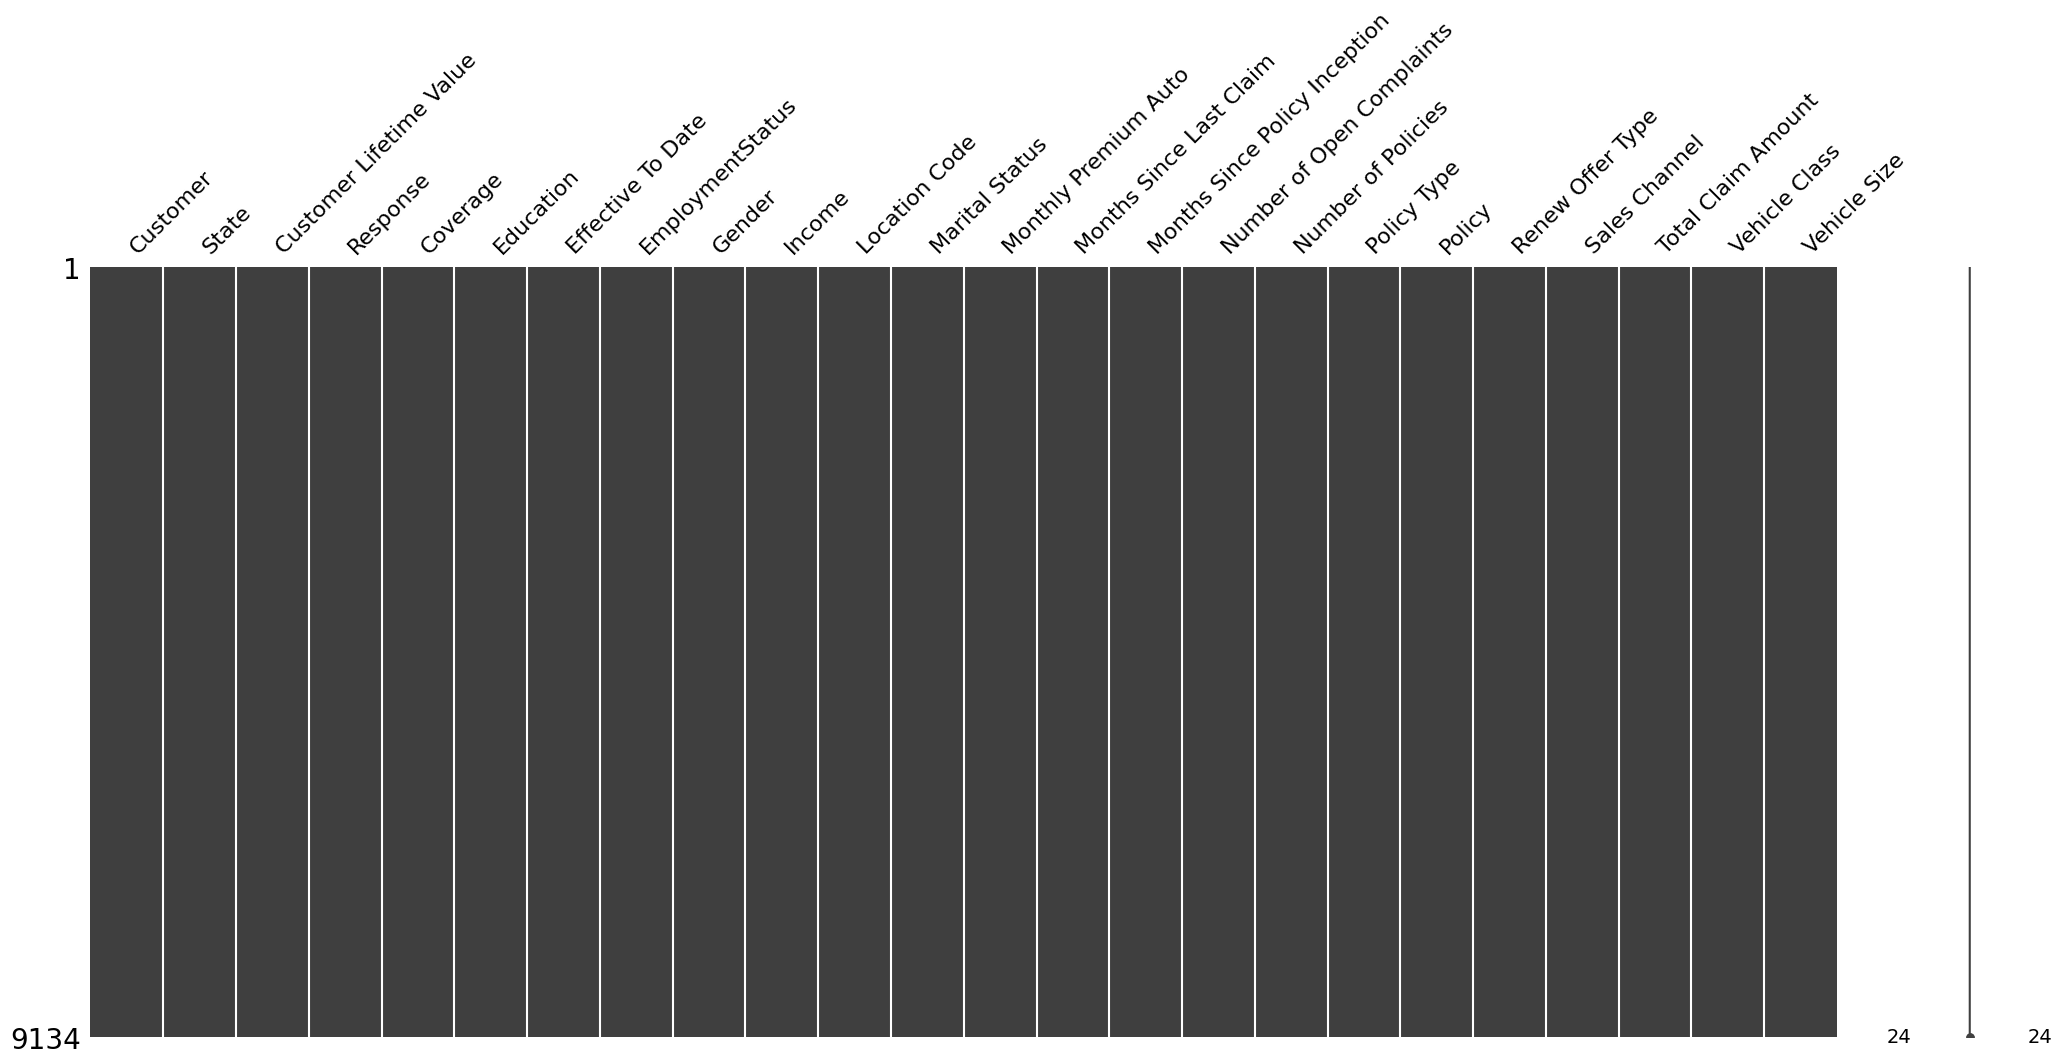

In [3]:
msgno.matrix(df)

#### **VISUALIZACIÓN DE DISTRIBUCIÓN DE VARIABLES NUMÉRICAS**

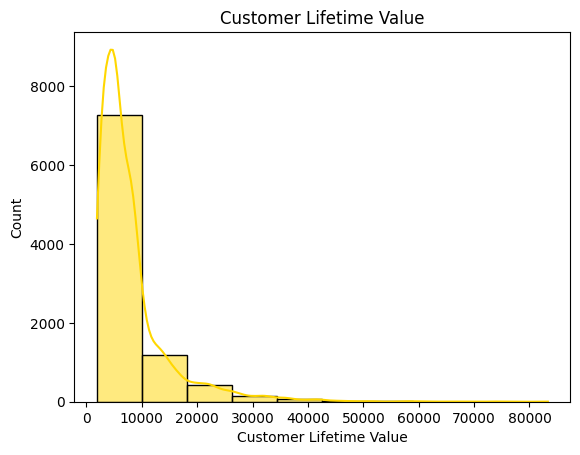

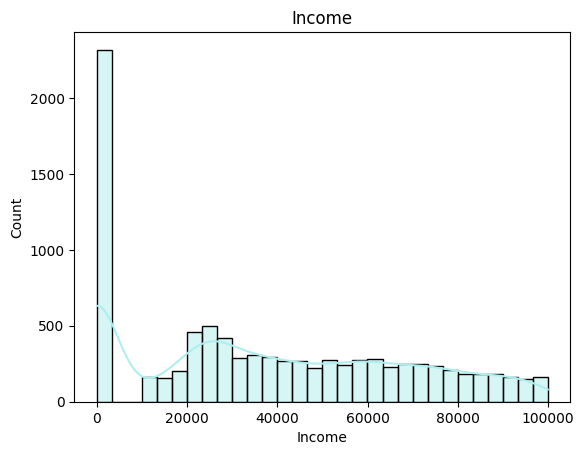

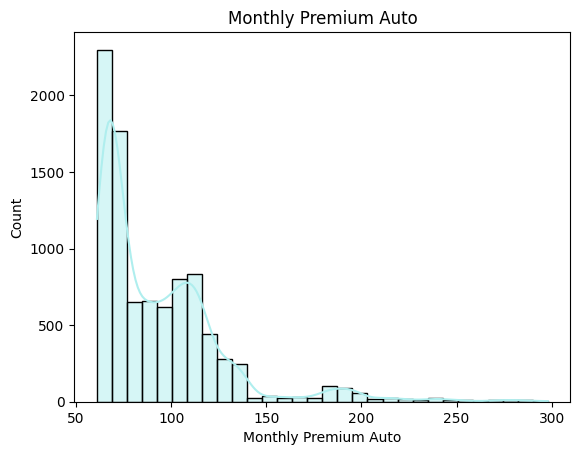

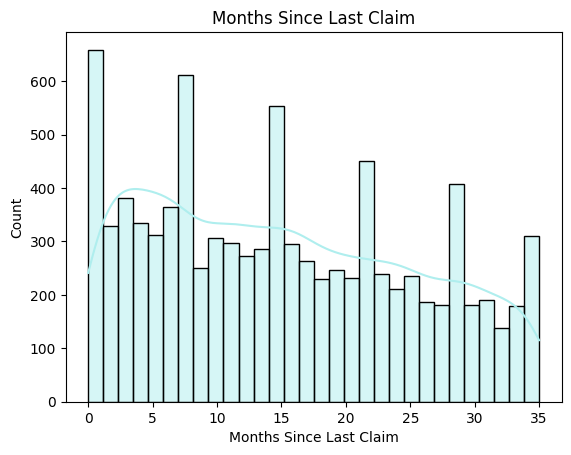

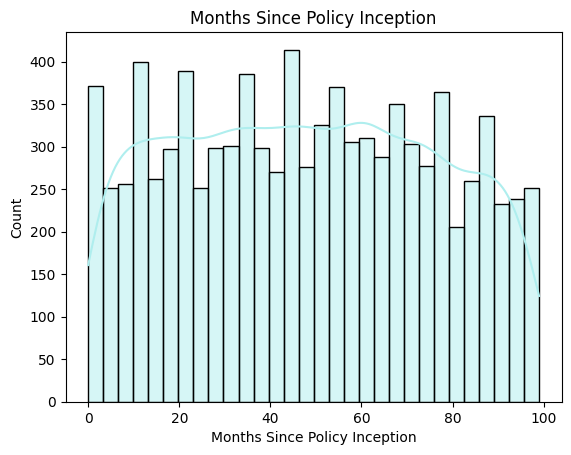

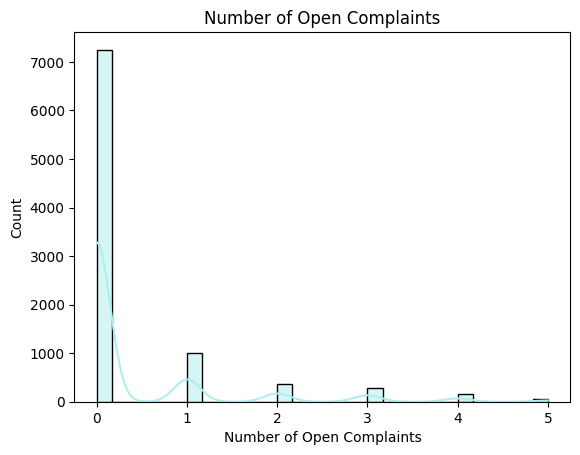

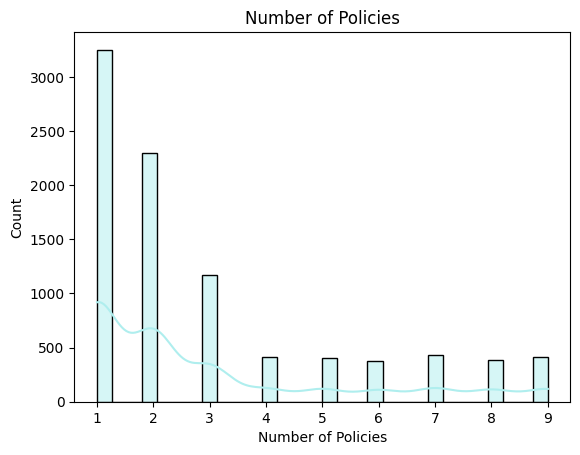

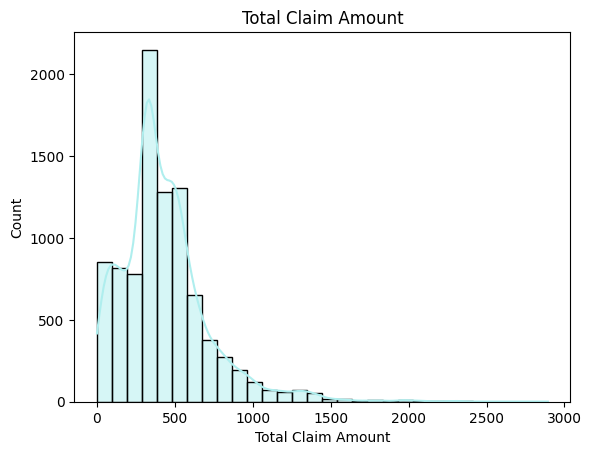

In [4]:
for col in df.select_dtypes(include=['int64', 'float64']).columns:
    plt.title(col)
    sns.histplot(
    x=df[col],
    kde=True,
    bins=10 if col == 'Customer Lifetime Value' else 30, 
    color='gold' if col == 'Customer Lifetime Value' else 'paleturquoise'
    )
    plt.show()

#### **VISUALIZACIÓN DE MATRIZ DE CORRELACIÓN ENTRE VARIABLES NUMÉRICAS**º

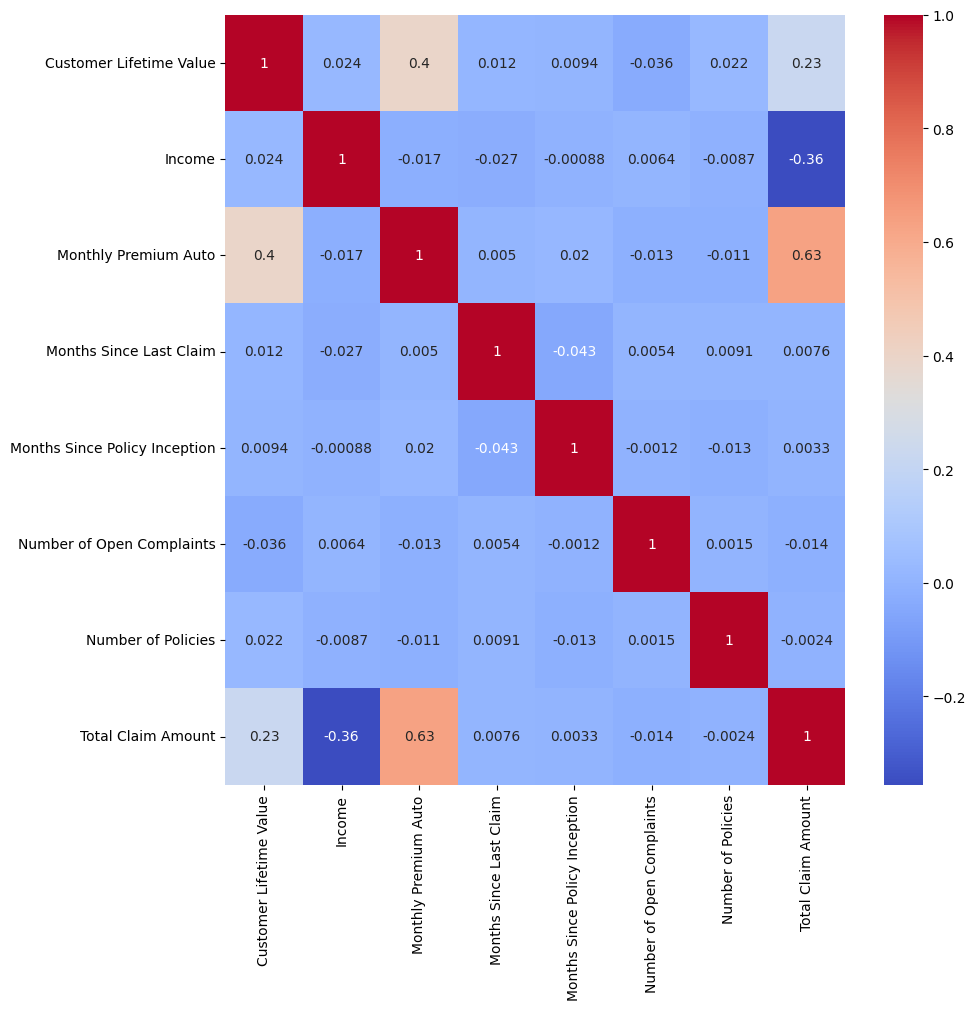

In [5]:
# Matriz de correlación
plt.figure(figsize=(10, 10))
sns.heatmap(df.corr(numeric_only=True), annot=True, cmap='coolwarm')
plt.show()

#### **TIPOS DE DATOS Y SELECCIÓN DE DATOS**

In [6]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 9134 entries, 0 to 9133
Data columns (total 24 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Customer                       9134 non-null   object 
 1   State                          9134 non-null   object 
 2   Customer Lifetime Value        9134 non-null   float64
 3   Response                       9134 non-null   object 
 4   Coverage                       9134 non-null   object 
 5   Education                      9134 non-null   object 
 6   Effective To Date              9134 non-null   object 
 7   EmploymentStatus               9134 non-null   object 
 8   Gender                         9134 non-null   object 
 9   Income                         9134 non-null   int64  
 10  Location Code                  9134 non-null   object 
 11  Marital Status                 9134 non-null   object 
 12  Monthly Premium Auto           9134 non-null   i

In [7]:
for col in df.columns:
    print(f'Únicos en columna {col}: {df[col].unique()} \n')

Únicos en columna Customer: ['BU79786' 'QZ44356' 'AI49188' ... 'TD14365' 'UP19263' 'Y167826'] 

Únicos en columna State: ['Washington' 'Arizona' 'Nevada' 'California' 'Oregon'] 

Únicos en columna Customer Lifetime Value: [ 2763.519279  6979.535903 12887.43165  ...  8163.890428  7524.442436
  2611.836866] 

Únicos en columna Response: ['No' 'Yes'] 

Únicos en columna Coverage: ['Basic' 'Extended' 'Premium'] 

Únicos en columna Education: ['Bachelor' 'College' 'Master' 'High School or Below' 'Doctor'] 

Únicos en columna Effective To Date: ['2/24/11' '1/31/11' '2/19/11' '1/20/11' '2/3/11' '1/25/11' '1/18/11'
 '1/26/11' '2/17/11' '2/21/11' '1/6/11' '2/6/11' '1/10/11' '1/17/11'
 '1/5/11' '2/27/11' '1/14/11' '1/21/11' '2/5/11' '1/29/11' '2/28/11'
 '2/12/11' '2/2/11' '2/7/11' '1/22/11' '2/13/11' '1/15/11' '1/8/11'
 '1/11/11' '1/28/11' '2/8/11' '2/23/11' '1/2/11' '2/16/11' '1/27/11'
 '1/23/11' '1/9/11' '2/11/11' '2/4/11' '2/1/11' '2/15/11' '2/26/11'
 '1/16/11' '1/1/11' '2/10/11' '1/24/11' '2

In [8]:
target = 'Customer Lifetime Value'

num_cols = [ 
    'Monthly Premium Auto', 
    'Months Since Last Claim', 
    'Months Since Policy Inception', 
    'Number of Open Complaints', 
    'Number of Policies',
]

interaction_cols = [
    'Income',
    'Total Claim Amount'
]

cat_cols = [
    'State',
    'Response',
    'EmploymentStatus',
    'Gender',
    'Location Code',
    'Marital Status',
    'Policy Type',
    'Policy',
    'Renew Offer Type',
    'Sales Channel',
    'Vehicle Class'
]

ordinal_cols = [
    'Coverage',
    'Vehicle Size',
    'Education'
]

#### **DECISIÓN DE VARIABLES ($X$ y $y$)**

In [9]:
X = df[num_cols + interaction_cols + cat_cols + ordinal_cols]
y = df[target]

#### **JUSTIFICACIÓN DE INTERACCIÓN ENTRE `Income` Y `Total Claim Amount`**

`P-value`

In [10]:
df_model = df.copy()

df_model = df_model.rename(
    columns={
    'Customer Lifetime Value': 'CLV',
    'Total Claim Amount': 'TotalClaimAmount'
})

model = smf.ols(
    formula='CLV ~ Income + TotalClaimAmount + Income:TotalClaimAmount',
    data=df_model
)

results = model.fit()

results.summary()

<class 'statsmodels.iolib.summary.Summary'>
"""
                            OLS Regression Results                            
==============================================================================
Dep. Variable:                    CLV   R-squared:                       0.064
Model:                            OLS   Adj. R-squared:                  0.064
Method:                 Least Squares   F-statistic:                     209.7
Date:                Thu, 07 May 2026   Prob (F-statistic):          1.43e-131
Time:                        23:12:33   Log-Likelihood:                -93355.
No. Observations:                9134   AIC:                         1.867e+05
Df Residuals:                    9130   BIC:                         1.867e+05
Df Model:                           3                                         
Covariance Type:            nonrobust                                         
===========================================================================================
                              coef    std err          t      P>|t|      [0.025      0.975]
-------------------------------------------------------------------------------------------
Intercept                4518.8451    218.188     20.711      0.000    4091.148    4946.542
Income                      0.0188      0.004      4.498      0.000       0.011       0.027
TotalClaimAmount            5.7720      0.351     16.440      0.000       5.084       6.460
Income:TotalClaimAmount  2.067e-05   8.38e-06      2.465      0.014    4.24e-06    3.71e-05
==============================================================================
Omnibus:                     5823.285   Durbin-Watson:                   1.996
Prob(Omnibus):                  0.000   Jarque-Bera (JB):            74019.083
Skew:                           2.916   Prob(JB):                         0.00
Kurtosis:                      15.668   Cond. No.                     6.20e+07
==============================================================================

Notes:
[1] Standard Errors assume that the covariance matrix of the errors is correctly specified.
[2] The condition number is large, 6.2e+07. This might indicate that there are
strong multicollinearity or other numerical problems.
"""

Se ajustó un modelo de regresión lineal auxiliar con el objetivo de analizar la relación entre `Income`, `Total Claim Amount` y `Customer Lifetime Value`. Los resultados mostraron que tanto `Income` como `Total Claim Amount` presentan coeficientes estadísticamente significativos, ya que sus valores p fueron menores a 0.05.

Además, se incluyó el término de interacción `Income:TotalClaimAmount`, el cual también resultó significativo con un valor p de aproximadamente 0.014. Esto indica que el efecto de `Total Claim Amount` sobre el `Customer Lifetime Value` no es completamente independiente del nivel de ingreso del cliente. En otras palabras, la relación entre el monto total reclamado y el valor de vida del cliente cambia dependiendo del ingreso.

Sin embargo, el modelo presentó un valor de $R^2 = 0.064$, lo que significa que solo explica aproximadamente el 6.4% de la variabilidad del `Customer Lifetime Value`. Por esta razón, aunque la interacción es estadísticamente significativa, el modelo lineal por sí solo tiene baja capacidad explicativa y no resulta suficiente como modelo predictivo final.


`ANOVA`

In [11]:
modelo_sin_interaccion = smf.ols(
    formula='CLV ~ Income + TotalClaimAmount',
    data=df_model
).fit()

modelo_con_interaccion = smf.ols(
    formula='CLV ~ Income + TotalClaimAmount + Income:TotalClaimAmount',
    data=df_model
).fit()

anova_result = sm.stats.anova_lm(modelo_sin_interaccion, modelo_con_interaccion)

anova_result

,df_resid,ssr,df_diff,ss_diff,F,Pr(>F)
0,9131.0,4.036394e+11,0.0,NaN,NaN,NaN
1,9130.0,4.033708e+11,1.0,2.685351e+08,6.078093,0.013705


Se realizó un análisis ANOVA para comparar dos modelos lineales: uno sin interacción y otro con la interacción entre `Income` y `Total Claim Amount`. El objetivo fue evaluar si agregar el término `Income:TotalClaimAmount` generaba una mejora estadísticamente significativa.

El resultado del ANOVA mostró un valor p de aproximadamente 0.013705. Como este valor es menor al nivel de significancia de 0.05, se rechaza la hipótesis nula de que la interacción no aporta mejora al modelo. Esto indica que el modelo con interacción se ajusta significativamente mejor que el modelo sin interacción.

Con base en este resultado, la interacción `Income × Total Claim Amount` puede considerarse una variable candidata para incluirse en modelos predictivos más complejos, como Random Forest y XGBoost. No obstante, debido a que estos modelos basados en árboles pueden capturar interacciones de manera natural, la utilidad final de esta variable debe evaluarse comparando el desempeño del modelo con y sin dicha interacción mediante validación cruzada.

#### **TRANSFORMACIÓN LOGARÍTMICA DE $y$ (ESTO PARA VER LA DISTRIBUCIÓN MÁS SEMEJANTE A UNA NORMAL Y FILTRAR OUTLIERS)** 

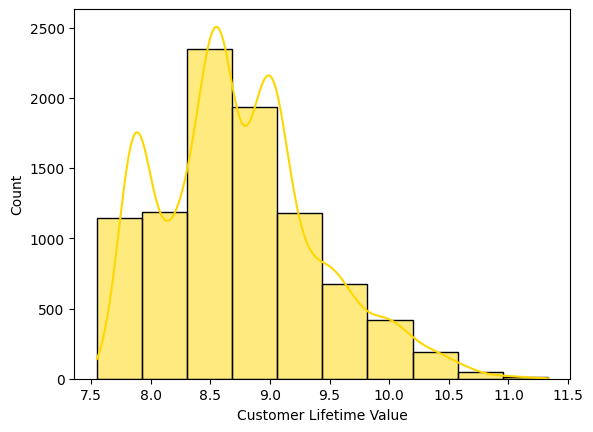

In [12]:
y_aux = np.log(y)
plt.figure()
sns.histplot(
    x=y_aux,
    kde=True,
    bins=10, 
    color='gold'
)
plt.show()

In [13]:
df_clean = df.copy()

In [14]:
df_clean['CLV_log'] = y_aux

#### **FILTRO DE OUTLIERS**

In [15]:
avg = np.mean(df_clean['CLV_log'])
std = np.std(df_clean['CLV_log'])

In [16]:
lim_lower = avg - 3 * std
lim_upper = avg + 3 * std

In [17]:
df_clean = df_clean[
    (df_clean['CLV_log'] >= lim_lower) & 
    (df_clean['CLV_log'] <= lim_upper)
]

In [18]:
df_clean.info()

<class 'pandas.core.frame.DataFrame'>
Index: 9102 entries, 0 to 9133
Data columns (total 25 columns):
 #   Column                         Non-Null Count  Dtype  
---  ------                         --------------  -----  
 0   Customer                       9102 non-null   object 
 1   State                          9102 non-null   object 
 2   Customer Lifetime Value        9102 non-null   float64
 3   Response                       9102 non-null   object 
 4   Coverage                       9102 non-null   object 
 5   Education                      9102 non-null   object 
 6   Effective To Date              9102 non-null   object 
 7   EmploymentStatus               9102 non-null   object 
 8   Gender                         9102 non-null   object 
 9   Income                         9102 non-null   int64  
 10  Location Code                  9102 non-null   object 
 11  Marital Status                 9102 non-null   object 
 12  Monthly Premium Auto           9102 non-null   int64 

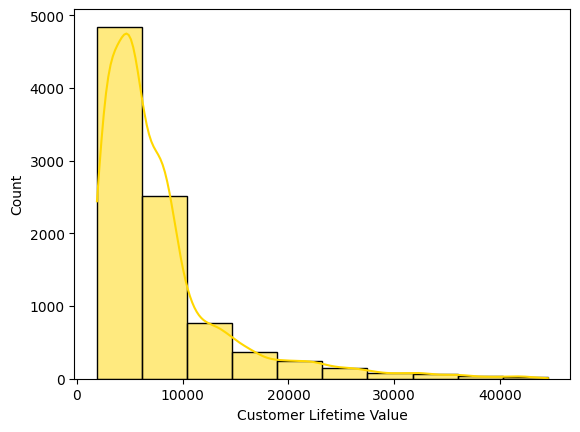

In [19]:
plt.figure()
sns.histplot(
    x=df_clean[target],
    kde=True,
    bins=10, 
    color='gold'
)
plt.show()

In [20]:
X = df_clean[num_cols + interaction_cols + cat_cols + ordinal_cols]
y = df_clean[target]

#### **SEPARACIÓN TRAIN-TEST 80/20**

In [21]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42) # Esto para probar el modelo final con datos no vistos

#### **TRANSFORMADORES**

In [22]:
order = [
    ['Basic', 'Extended', 'Premium'],
    ['Small', 'Medsize', 'Large'],
    ['High School or Below', 'College', 'Bachelor', 'Master', 'Doctor']
]

In [23]:
num_transformer = StandardScaler() 
cat_transformer = OneHotEncoder(
    drop='first',
    handle_unknown='ignore'
)
ord_transformer = OrdinalEncoder(
    categories=order
)

In [24]:
pf = PolynomialFeatures(
    degree=2,
    interaction_only=True,
    include_bias=False
)

interaction_transformer = Pipeline(
    steps=[
        ('interaction', pf),
        ('scaler', num_transformer)
    ]
)

In [25]:
transformer = ColumnTransformer(
    transformers=[
        ('numeric', num_transformer, num_cols),
        ('interaction', interaction_transformer, interaction_cols),
        ('categoric', cat_transformer, cat_cols),
        ('ordinal', ord_transformer, ordinal_cols)
    ]
)

#### **MODELOS PROPUESTOS**

#### `RandomForestRegressor`

In [26]:
rdf_model = RandomForestRegressor(
    random_state=42, 
    n_jobs=-1 # Usa todos los núcleos disponibles de la computadora para paralelizar el trabajo
)

In [27]:
pipeline_rdf = Pipeline(
    steps=[
        ('preprocessor', transformer),
        ('model', rdf_model)
    ]
)

In [28]:
final_model_rdf = TransformedTargetRegressor(
    regressor=pipeline_rdf,
    func=np.log1p,
    inverse_func=np.expm1
)

#### `XGBRegressor`

In [29]:
xgb_model = XGBRegressor(
    random_state=42,
    n_jobs=-1 # Usa todos los núcleos disponibles de la computadora para paralelizar el trabajo
)

In [30]:
pipeline_xgb = Pipeline(
    steps=[
        ('preprocessor', transformer),
        ('model', xgb_model)
    ]
)

In [31]:
final_model_xgb = TransformedTargetRegressor(
    regressor=pipeline_xgb,
    func=np.log1p,
    inverse_func=np.expm1
)

#### **HIPERPARÁMETROS A OPTIMIZAR DE CADA MODELO (ESPACIO DE BÚSQUEDA)**

#### `RandomForestRegressor`

In [32]:
search_space_rdf = {
    # Número de árboles del bosque.
    # Más árboles suelen dar predicciones más estables, pero aumentan el tiempo de entrenamiento.
    'regressor__model__n_estimators': Integer(300, 1000),

    # Profundidad máxima de cada árbol.
    # Controla qué tan complejos pueden ser los árboles.
    # Valores altos pueden causar sobreajuste.
    'regressor__model__max_depth': Integer(2, 30),

    # Número máximo de hojas finales que puede tener cada árbol.
    # Ayuda a limitar el tamaño del árbol y reducir sobreajuste.
    'regressor__model__max_leaf_nodes': Integer(5, 200),

    # Número mínimo de observaciones necesarias para dividir un nodo interno.
    # Valores altos hacen que el modelo sea más conservador.
    'regressor__model__min_samples_split': Integer(2, 30),

    # Número mínimo de observaciones que debe tener una hoja final.
    # Valores altos suavizan el modelo y reducen sobreajuste.
    'regressor__model__min_samples_leaf': Integer(1, 20),

    # Porcentaje o cantidad de variables que se consideran al buscar la mejor división.
    # Valores menores aumentan la aleatoriedad entre árboles y pueden reducir sobreajuste.
    'regressor__model__max_features': Real(0.5, 1.0),

    # Porcentaje de muestras usadas para entrenar cada árbol cuando bootstrap=True.
    # Ayuda a que los árboles sean menos parecidos entre sí.
    'regressor__model__max_samples': Real(0.6, 1.0)
}

#### `XGBRegressor`

In [33]:
search_space_xgb = {
    # Número de árboles secuenciales que construye XGBoost.
    # Más árboles pueden mejorar el ajuste, pero también aumentan el riesgo de sobreajuste.
    'regressor__model__n_estimators': Integer(100, 1500),

    # Profundidad máxima de cada árbol.
    # Controla qué tan complejas pueden ser las relaciones que aprende el modelo.
    'regressor__model__max_depth': Integer(2, 10),

    # Número máximo de hojas que puede tener cada árbol.
    # Es útil para controlar la complejidad del árbol, especialmente con tree_method='hist'.
    'regressor__model__max_leaves': Integer(0, 100),

    # Tasa de aprendizaje.
    # Controla qué tanto aporta cada árbol nuevo al modelo final.
    # Valores bajos suelen requerir más árboles.
    'regressor__model__learning_rate': Real(0.01, 0.3, prior='log-uniform'), # Se mueve mejor en escala multiplicativa, no en escala lineal.

    # Peso mínimo necesario en un nodo hijo para permitir una nueva división.
    # Valores altos hacen que el modelo sea más conservador y evitan divisiones débiles.
    'regressor__model__min_child_weight': Integer(1, 20),

    # Porcentaje de filas usadas para entrenar cada árbol.
    # Valores menores a 1 ayudan a reducir sobreajuste.
    'regressor__model__subsample': Real(0.5, 1.0),

    # Porcentaje de columnas usadas para entrenar cada árbol.
    # Ayuda a reducir sobreajuste y hace que los árboles sean más diversos.
    'regressor__model__colsample_bytree': Real(0.5, 1.0),

    # Reducción mínima de la función de pérdida necesaria para hacer una división.
    # Valores altos hacen que el modelo sea más conservador.
    'regressor__model__gamma': Real(0.0, 5.0),

    # Regularización L1.
    # Puede ayudar a reducir la complejidad del modelo y seleccionar variables menos relevantes.
    'regressor__model__reg_alpha': Real(1e-5, 1.0, prior='log-uniform'), # Se mueve mejor en escala multiplicativa, no en escala lineal.

    # Regularización L2.
    # Ayuda a controlar sobreajuste penalizando pesos grandes.
    'regressor__model__reg_lambda': Real(0.5, 10.0)
}

#### **CROSS VALIDATION CON** `RepeatedKFold`

In [34]:
cv = RepeatedKFold(
    n_splits=5, # Número de particiones.
    n_repeats=4, # Número de veces que hará las particiones.
    random_state=42
)

#### **OPTIMIZACIÓN BAYESIANA PARA ENCONTRAR EL MEJOR MODELO DE** `RandomForestRegressor`

In [35]:
opt_rdf = BayesSearchCV(
    estimator=final_model_rdf,
    search_spaces=search_space_rdf,
    n_iter=40,
    scoring='neg_root_mean_squared_error',
    cv=cv,
    n_jobs=-1,
    random_state=42
)

In [36]:
opt_rdf.fit(X_train, y_train)

,estimator,TransformedTa..._state=42))]))
,search_spaces,"{'regressor__model__max_depth': Integer(low=2...m='normalize'), 'regressor__model__max_features': Real(low=0.5,...m='normalize'), 'regressor__model__max_leaf_nodes': Integer(low=5...m='normalize'), 'regressor__model__max_samples': Real(low=0.6,...m='normalize'), ...}"
,optimizer_kwargs,None
,n_iter,40
,scoring,'neg_root_mean_squared_error'
,fit_params,None
,n_jobs,-1
,n_points,1
,iid,'deprecated'
,refit,True
,cv,RepeatedKFold...ndom_state=42)


In [37]:
print('Mejores hiperparámetros de Random Forest:')
print(opt_rdf.best_params_, '\n')

print(f'Mejor RMSE de cross-validation: {-opt_rdf.best_score_}')

Mejores hiperparámetros de Random Forest:
OrderedDict([('regressor__model__max_depth', 30), ('regressor__model__max_features', 1.0), ('regressor__model__max_leaf_nodes', 200), ('regressor__model__max_samples', 0.6022301344547701), ('regressor__model__min_samples_leaf', 1), ('regressor__model__min_samples_split', 2), ('regressor__model__n_estimators', 1000)]) 

Mejor RMSE de cross-validation: 3269.349276708778


In [38]:
best_rdf = opt_rdf.best_estimator_
best_rdf

,regressor,Pipeline(step...m_state=42))])
,transformer,None
,func,<ufunc 'log1p'>
,inverse_func,<ufunc 'expm1'>
,check_inverse,True
,transformers,"[('numeric', ...), ('interaction', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False


#### **OPTIMIZACIÓN BAYESIANA PARA ENCONTRAR EL MEJOR MODELO DE** `XGBRegressor`

In [39]:
opt_xgb = BayesSearchCV(
    estimator=final_model_xgb,
    search_spaces=search_space_xgb,
    n_iter=40,
    scoring='neg_root_mean_squared_error',
    cv=cv,
    n_jobs=-1,
    random_state=42,
)

In [40]:
opt_xgb.fit(X_train, y_train)

,estimator,"TransformedTa...None, ...))]))"
,search_spaces,"{'regressor__model__colsample_bytree': Real(low=0.5,...m='normalize'), 'regressor__model__gamma': Real(low=0.0,...m='normalize'), 'regressor__model__learning_rate': Real(low=0.01...m='normalize'), 'regressor__model__max_depth': Integer(low=2...m='normalize'), ...}"
,optimizer_kwargs,None
,n_iter,40
,scoring,'neg_root_mean_squared_error'
,fit_params,None
,n_jobs,-1
,n_points,1
,iid,'deprecated'
,refit,True
,cv,RepeatedKFold...ndom_state=42)


In [41]:
print('Mejores hiperparámetros de XGBoost:')
print(opt_xgb.best_params_, '\n')

print(f'Mejor RMSE de cross-validation: {-opt_xgb.best_score_}')

Mejores hiperparámetros de XGBoost:
OrderedDict([('regressor__model__colsample_bytree', 1.0), ('regressor__model__gamma', 0.0), ('regressor__model__learning_rate', 0.017861797513366112), ('regressor__model__max_depth', 10), ('regressor__model__max_leaves', 55), ('regressor__model__min_child_weight', 18), ('regressor__model__n_estimators', 1218), ('regressor__model__reg_alpha', 0.0020679814260193734), ('regressor__model__reg_lambda', 0.5119975469864121), ('regressor__model__subsample', 0.9091950118440635)]) 

Mejor RMSE de cross-validation: 3297.371730224399


In [42]:
best_xgb = opt_xgb.best_estimator_
best_xgb

,regressor,"Pipeline(step...=None, ...))])"
,transformer,None
,func,<ufunc 'log1p'>
,inverse_func,<ufunc 'expm1'>
,check_inverse,True
,transformers,"[('numeric', ...), ('interaction', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False


#### **ENTRENAMIENTO, $RMSE$ Y $R^2$ DE AMBOS MODELOS $X_{train}$**

In [43]:
def evaluar_modelo(modelo, X_test, y_test, nombre):
    'Función que trabaja con un modelo, una matriz X y un vector y para dar diferentes scores: RMSE y R²'
    y_pred = modelo.predict(X_test)

    rmse = root_mean_squared_error(y_test, y_pred)
    r2 = r2_score(y_test, y_pred)

    return {
        'Modelo': nombre,
        'RMSE': rmse,
        'R²': r2
    }

`RandomForestRegressor`

In [44]:
best_rdf.fit(X_train, y_train)

,regressor,Pipeline(step...m_state=42))])
,transformer,None
,func,<ufunc 'log1p'>
,inverse_func,<ufunc 'expm1'>
,check_inverse,True
,transformers,"[('numeric', ...), ('interaction', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False


`XGBRegressor`

In [45]:
best_xgb.fit(X_train, y_train)

,regressor,"Pipeline(step...=None, ...))])"
,transformer,None
,func,<ufunc 'log1p'>
,inverse_func,<ufunc 'expm1'>
,check_inverse,True
,transformers,"[('numeric', ...), ('interaction', ...), ...]"
,remainder,'drop'
,sparse_threshold,0.3
,n_jobs,None
,transformer_weights,None
,verbose,False


$RMSE$ Y $R^2$

In [46]:
metricas_train = pd.DataFrame([
    evaluar_modelo(best_rdf, X_train, y_train, 'Random Forest'),
    evaluar_modelo(best_xgb, X_train, y_train, 'XGBoost')
])

metricas_train

,Modelo,RMSE,R²
0,Random Forest,2170.416515,0.876829
1,XGBoost,1863.619812,0.909189


In [47]:
modelos_optimizados_cv = {
    'Random Forest': best_rdf,
    'XGBoost': best_xgb
}

resultados_optimizados_cv = []

In [48]:
for nombre, modelo in modelos_optimizados_cv.items():
    scores = cross_val_score(
        estimator=modelo,
        X=X_train,
        y=y_train,
        scoring='neg_root_mean_squared_error',
        cv=cv,
        n_jobs=-1
    )

    rmse_scores = -scores

    resultados_optimizados_cv.append({
        'Modelo': nombre,
        'RMSE avg CV': rmse_scores.mean(),
        'RMSE std CV': rmse_scores.std()
    })

In [49]:
resultados_optimizados_cv = pd.DataFrame(resultados_optimizados_cv)
resultados_optimizados_cv

,Modelo,RMSE avg CV,RMSE std CV
0,Random Forest,3269.349277,207.416283
1,XGBoost,3297.371730,221.779134


In [50]:
tabla_final = pd.merge(
    metricas_train,
    resultados_optimizados_cv,
    on='Modelo',
    how='inner'
)

tabla_final

,Modelo,RMSE,R²,RMSE avg CV,RMSE std CV
0,Random Forest,2170.416515,0.876829,3269.349277,207.416283
1,XGBoost,1863.619812,0.909189,3297.371730,221.779134


#### **COMPARACIÓN DE $RMSE$ Y $R^2$ DE AMBOS MODELOS CON DATOS NUEVOS $X_{test}$**


In [51]:
metricas_test = pd.DataFrame([
    evaluar_modelo(best_rdf, X_test, y_test, 'Random Forest'),
    evaluar_modelo(best_xgb, X_test, y_test, 'XGBoost')
])

metricas_test

,Modelo,RMSE,R²
0,Random Forest,3337.762505,0.737524
1,XGBoost,3434.912537,0.722022


#### **GRAFICO DE DATOS REALES VS. DATOS PREDICHOS**

In [52]:
def graficar_reales_vs_predichos(y_test, y_pred, nombre):
    plt.figure(figsize=(8, 6))
    
    sns.scatterplot(
        x=y_test,
        y=y_pred,
        alpha=0.7,
        color='lightgreen'
    )
    
    min_val = min(y_test.min(), y_pred.min())
    max_val = max(y_test.max(), y_pred.max())
    
    sns.lineplot(
        x=[min_val, max_val],
        y=[min_val, max_val],
        color='black',
        linestyle='--'
    )
    
    plt.xlabel('Valores reales')
    plt.ylabel('Valores predichos')
    plt.title(f'Reales vs Predichos - {nombre}')
    plt.show()

In [53]:
y_pred_rdf = best_rdf.predict(X_test)
y_pred_xgb = best_xgb.predict(X_test)

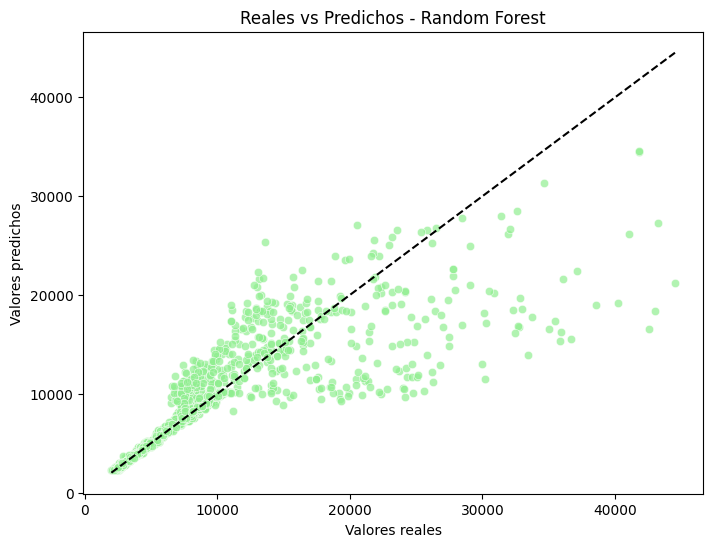

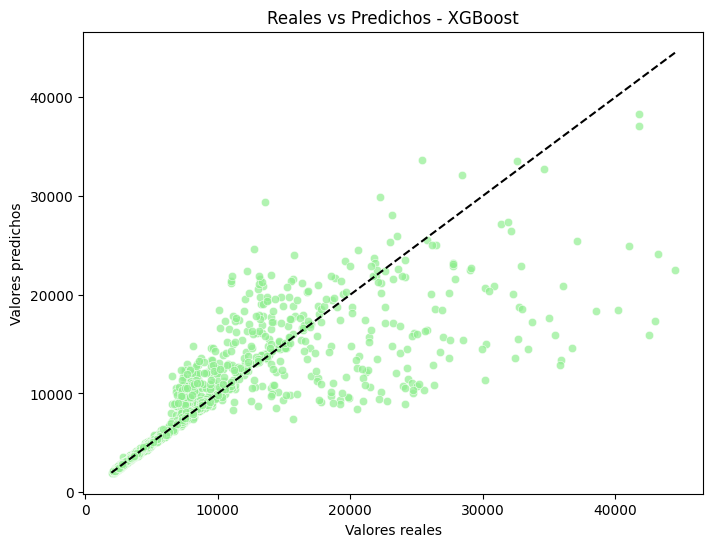

In [54]:
graficar_reales_vs_predichos(
    y_test=y_test,
    y_pred=y_pred_rdf,
    nombre='Random Forest'
)

graficar_reales_vs_predichos(
    y_test=y_test,
    y_pred=y_pred_xgb,
    nombre='XGBoost'
)

#### **TABLA FINAL DE MÉTRICAS ($RMSE$ Y $R^2$)**

$Train$

In [55]:
tabla_final

,Modelo,RMSE,R²,RMSE avg CV,RMSE std CV
0,Random Forest,2170.416515,0.876829,3269.349277,207.416283
1,XGBoost,1863.619812,0.909189,3297.371730,221.779134


$Test$

In [56]:
metricas_test

,Modelo,RMSE,R²
0,Random Forest,3337.762505,0.737524
1,XGBoost,3434.912537,0.722022


# **Pipeline**

# **Conclusión**

# **Referencias**

Breiman, L. (1996). Bagging predictors. Machine Learning, 24(2), 123–140. https://doi.org/10.1007/BF00058655

Breiman, L. (2001). Random forests. Machine Learning, 45(1), 5–32. https://doi.org/10.1023/A:1010933404324

Chen, T., & Guestrin, C. (2016). XGBoost: A scalable tree boosting system. Proceedings of the 22nd ACM SIGKDD International Conference on Knowledge Discovery and Data Mining, 785–794. https://doi.org/10.1145/2939672.2939785

Dietterich, T. G. (2000). Ensemble methods in machine learning. En J. Kittler & F. Roli (Eds.), Multiple classifier systems (Lecture Notes in Computer Science, vol. 1857, pp. 1–15). Springer. https://doi.org/10.1007/3-540-45014-9_1

Efron, B., & Tibshirani, R. J. (1993). An introduction to the bootstrap. Chapman & Hall.

Freund, Y., & Schapire, R. E. (1997). A decision-theoretic generalization of on-line learning and an application to boosting. Journal of Computer and System Sciences, 55(1), 119–139. https://www.sciencedirect.com/science/article/pii/S002200009791504X

James, G., Witten, D., Hastie, T., Tibshirani, R., & Taylor, J. (2023). An introduction to statistical learning: With applications in Python. Springer. https://www.statlearning.com

Kaggle. (s.f.). Customer Value Analysis. Recuperado de: https://www.kaggle.com

Loh, W.-Y. (2014). Fifty years of classification and regression trees. International Statistical Review, 82(3), 329–348. https://doi.org/10.1111/insr.12016

scikit-learn. (2026a). RandomForestRegressor. scikit-learn documentation. Recuperado el 7 de mayo de 2026, de https://scikit-learn.org/stable/modules/generated/sklearn.ensemble.RandomForestRegressor.html

scikit-learn. (2026b). RepeatedKFold. scikit-learn documentation. Recuperado el 7 de mayo de 2026, de https://scikit-learn.org/stable/modules/generated/sklearn.model_selection.RepeatedKFold.html

scikit-learn. (2026c). TransformedTargetRegressor. scikit-learn documentation. Recuperado el 7 de mayo de 2026, de https://scikit-learn.org/stable/modules/generated/sklearn.compose.TransformedTargetRegressor.html

SciPy. (2026). scipy.stats.boxcox. SciPy documentation. Recuperado el 7 de mayo de 2026, de https://docs.scipy.org/doc/scipy/reference/generated/scipy.stats.boxcox.html

Seabold, S., & Perktold, J. (2010). Statsmodels: Econometric and statistical modeling with Python. Proceedings of the 9th Python in Science Conference, 92–96. https://doi.org/10.25080/Majora-92bf1922-011

statsmodels. (2026). statsmodels.stats.anova.anova_lm. statsmodels documentation. Recuperado el 7 de mayo de 2026, de https://www.statsmodels.org/stable/generated/statsmodels.stats.anova.anova_lm.html

XGBoost developers. (2026). XGBoost parameters. XGBoost documentation. Recuperado el 7 de mayo de 2026, de https://xgboost.readthedocs.io/en/stable/parameter.html